<a href="https://colab.research.google.com/github/mvaraujo1977/Algoritmo-Genetico/blob/main/02_otimizacao_hiperparametros_ag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Otimização de Modelos de Diagnóstico e Interpretação com IA Generativa
## Tech Challenge - Fase 2 | IA para Devs

Este projeto dá continuidade à solução desenvolvida na fase anterior para classificação de registros clínicos relacionados à tireoide. A proposta combina Algoritmos Genéticos para otimização automática de hiperparâmetros dos modelos de Machine Learning e Large Language Models (LLMs) para interpretação dos resultados em linguagem natural.

O objetivo é melhorar o desempenho dos modelos diagnósticos por meio de técnicas evolucionárias e transformar predições, probabilidades e métricas em explicações mais acessíveis e úteis para profissionais da saúde.

A solução possui caráter acadêmico e experimental. Os resultados gerados devem ser utilizados apenas como apoio à análise clínica, não substituindo a avaliação e o julgamento de profissionais da saúde.

## Arquitetura da solução

A solução foi organizada em componentes independentes para treinamento, interpretação e disponibilização do modelo. O conjunto de teste permanece reservado para a avaliação final, enquanto a otimização utiliza validação cruzada apenas sobre os dados de treino.

~~~text
Dataset clínico
      |
      v
Limpeza e divisão estratificada
      |
      +------------------------+
      |                        |
      v                        v
Random Forest baseline   Algoritmo Genético
                               |
                               v
                     Validação cruzada (3 folds)
                               |
                               v
                       Modelo otimizado
                               |
                 +-------------+-------------+
                 |                           |
                 v                           v
          Interpretação por LLM       Artefato Joblib
                                             |
                                             v
                                      API FastAPI
                                             |
                         +-------------------+-------------------+
                         |                   |                   |
                         v                   v                   v
                    Logging JSON      Métricas Prometheus   Cloud Run
                                                               |
                                                               v
                                                      Escalabilidade automática
~~~

O notebook concentra a preparação dos dados, a otimização e a análise dos resultados. A API carrega o artefato salvo e fornece os endpoints de saúde, predição, métricas e documentação interativa.


## 1. Preparação do Ambiente

A execução do projeto foi planejada para o Google Colab, permitindo o carregamento automático dos dados e a reprodução dos experimentos em ambiente padronizado. A célula a seguir realiza as configurações iniciais do ambiente e pode incluir a instalação de dependências necessárias para a execução das etapas de otimização por Algoritmos Genéticos e interpretação dos resultados com LLMs.


In [ ]:
# Dependências necessárias para execução no Google Colab
%pip install -q "deap>=1.4,<2.0" "openai>=1.66,<3.0"

## 2. Importação das Bibliotecas

O projeto utiliza bibliotecas para análise de dados, visualização, treinamento e avaliação de modelos de Machine Learning, além de recursos para implementação do Algoritmo Genético empregado na otimização de hiperparâmetros. O parâmetro `RANDOM_STATE` foi adotado para aumentar a reprodutibilidade dos resultados.


In [ ]:
import json
import logging
import os
import random
import subprocess
import sys
import time
import urllib.request
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from deap import base, creator, tools, algorithms
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET_COLUMN = "target"
POSITIVE_LABEL = "hypothyroid"
NEGATIVE_LABEL = "negative"

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f"Seed global definida: {RANDOM_STATE}")


Seed global definida: 42


## 3. Fonte de Dados e Diretórios do Projeto

O dataset hypothyroid_final.csv é carregado automaticamente do GitHub no Google Colab ou da pasta dataset/ em ambiente local. Os diretórios necessários para armazenamento dos resultados são criados durante a execução.

In [ ]:
GITHUB_DATA_URL = (
    "https://raw.githubusercontent.com/"
    "mvaraujo1977/TechCahllenge_Tireoide/"
    "Nirton_Afonso/dataset/hypothyroid_final.csv"
)

RUNNING_IN_COLAB = "google.colab" in sys.modules

if RUNNING_IN_COLAB:
    PROJECT_ROOT = Path("/content/tech-challenge-ia-saude")
    if not (PROJECT_ROOT / ".git").exists():
        print("Clonando o repositório da Fase 2 para o ambiente Colab...")
        subprocess.run(
            [
                "git", "clone", "--depth", "1",
                "--branch", "Nirton", "--single-branch",
                "https://github.com/Val-Faria/tech-challenge-ia-saude.git",
                str(PROJECT_ROOT)
            ],
            check=True
        )
    DATA_DIR = PROJECT_ROOT / "dataset"
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    DATA_PATH = DATA_DIR / "hypothyroid_final.csv"

    print("Ambiente Google Colab detectado.")
    print(f"Baixando dataset do GitHub para: {DATA_PATH}")
    urllib.request.urlretrieve(GITHUB_DATA_URL, DATA_PATH)
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name.lower() == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

    DATA_PATH = PROJECT_ROOT / "dataset" / "hypothyroid_final.csv"
    if not DATA_PATH.exists():
        DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
        print("Dataset local não encontrado. Baixando do GitHub para a pasta dataset/ do projeto.")
        urllib.request.urlretrieve(GITHUB_DATA_URL, DATA_PATH)

MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
RESULTS_DIR = PROJECT_ROOT / "reports" / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

LOG_PATH = RESULTS_DIR / "execucao.log"
logger = logging.getLogger("tech_challenge")
logger.setLevel(logging.INFO)
logger.handlers.clear()
log_formatter = logging.Formatter(
    "%(asctime)s | %(levelname)s | %(message)s"
)
file_handler = logging.FileHandler(LOG_PATH, encoding="utf-8")
file_handler.setFormatter(log_formatter)
stream_handler = logging.StreamHandler()
stream_handler.setFormatter(log_formatter)
logger.addHandler(file_handler)
logger.addHandler(stream_handler)
logger.propagate = False
logger.info(
    "Ambiente inicializado colab=%s dataset=%s",
    RUNNING_IN_COLAB,
    DATA_PATH
)

print(f"Fonte GitHub: {GITHUB_DATA_URL}")
print(f"Dataset em uso: {DATA_PATH.resolve()}")
print(f"Diretório de modelos: {MODELS_DIR.resolve()}")
print(f"Diretório de figuras: {FIGURES_DIR.resolve()}")
print(f"Diretório de resultados: {RESULTS_DIR.resolve()}")
print(f"Arquivo de log: {LOG_PATH.resolve()}")

Clonando o repositório da Fase 2 para o ambiente Colab...
Ambiente Google Colab detectado.
Baixando dataset do GitHub para: /content/tech-challenge-ia-saude/dataset/hypothyroid_final.csv


2026-07-13 03:51:50,413 | INFO | Ambiente inicializado colab=True dataset=/content/tech-challenge-ia-saude/dataset/hypothyroid_final.csv


Fonte GitHub: https://raw.githubusercontent.com/mvaraujo1977/TechCahllenge_Tireoide/Nirton_Afonso/dataset/hypothyroid_final.csv
Dataset em uso: /content/tech-challenge-ia-saude/dataset/hypothyroid_final.csv
Diretório de modelos: /content/tech-challenge-ia-saude/models
Diretório de figuras: /content/tech-challenge-ia-saude/reports/figures
Diretório de resultados: /content/tech-challenge-ia-saude/reports/results
Arquivo de log: /content/tech-challenge-ia-saude/reports/results/execucao.log


## 4. Carregamento do Dataset

O conjunto de dados será carregado para o treinamento do modelo Random Forest e para a avaliação das diferentes configurações de hiperparâmetros exploradas pelo Algoritmo Genético.

In [ ]:
dados = pd.read_csv(DATA_PATH, na_values=["?", "", "NA", "NaN"])

print(f"Dataset carregado com sucesso!")
print(f"Dimensões: {dados.shape[0]} linhas × {dados.shape[1]} colunas")

display(dados.head())

Dataset carregado com sucesso!
Dimensões: 3163 linhas × 26 colunas


,target,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG
0,hypothyroid,72.0,M,f,f,f,f,f,f,f,...,y,0.6,y,15.0,y,1.48,y,10.0,n,NaN
1,hypothyroid,15.0,F,t,f,f,f,f,f,f,...,y,1.7,y,19.0,y,1.13,y,17.0,n,NaN
2,hypothyroid,24.0,M,f,f,f,f,f,f,f,...,y,0.2,y,4.0,y,1.00,y,0.0,n,NaN
3,hypothyroid,24.0,F,f,f,f,f,f,f,f,...,y,0.4,y,6.0,y,1.04,y,6.0,n,NaN
4,hypothyroid,77.0,M,f,f,f,f,f,f,f,...,y,1.2,y,57.0,y,1.28,y,44.0,n,NaN


## 5. Limpeza dos Dados

A limpeza adotou uma postura conservadora, adequada ao contexto médico. Registros duplicados foram removidos para reduzir viés amostral, enquanto valores extremos foram mantidos por sua possível relevância clínica. O tratamento de ausentes foi reservado ao pipeline de modelagem.

In [ ]:
dados_limpos = dados.copy()
antes = len(dados_limpos)
dados_limpos = dados_limpos.drop_duplicates().reset_index(drop=True)
depois = len(dados_limpos)

print(f"Registros antes: {antes}")
print(f"Registros após remoção de duplicados: {depois}")
print(f"Duplicados removidos: {antes - depois}")

dados_limpos = dados_limpos[dados_limpos[TARGET_COLUMN].isin([NEGATIVE_LABEL, POSITIVE_LABEL])].reset_index(drop=True)

print("Distribuição após limpeza:")
display(dados_limpos[TARGET_COLUMN].value_counts().to_frame("quantidade"))

Registros antes: 3163
Registros após remoção de duplicados: 3086
Duplicados removidos: 77
Distribuição após limpeza:


,quantidade
target,
negative,2945
hypothyroid,141


In [ ]:
checks = []
if "age" in dados_limpos.columns:
    checks.append({
        "variavel": "age",
        "menor_que_zero": int((dados_limpos["age"] < 0).sum()),
        "maior_que_120": int((dados_limpos["age"] > 120).sum()),
    })

for col in ["TSH", "T3", "TT4", "T4U", "FTI", "TBG"]:
    if col in dados_limpos.columns:
        checks.append({
            "variavel": col,
            "menor_que_zero": int((dados_limpos[col] < 0).sum()),
            "maior_que_120": np.nan,
        })

display(pd.DataFrame(checks))

,variavel,menor_que_zero,maior_que_120
0,age,0,0.0
1,TSH,0,NaN
2,T3,0,NaN
3,TT4,0,NaN
4,T4U,0,NaN
5,FTI,0,NaN
6,TBG,0,NaN


## 6. Separação entre Variáveis Preditoras e Variável-Alvo

Nesta etapa, o dataset é dividido em variáveis preditoras (`X`) e variável-alvo (`y`). Essa separação é essencial para estruturar o problema de aprendizado supervisionado, permitindo o treinamento do modelo Random Forest e a avaliação das diferentes combinações de hiperparâmetros exploradas pelo Algoritmo Genético.

In [ ]:
X = dados_limpos.drop(columns=[TARGET_COLUMN])
y = dados_limpos[TARGET_COLUMN].map({NEGATIVE_LABEL: 0, POSITIVE_LABEL: 1})

print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")
print("Mapeamento: 0 = negative, 1 = hypothyroid")
display(y.value_counts().rename(index={0: NEGATIVE_LABEL, 1: POSITIVE_LABEL}).to_frame("quantidade"))

Formato de X: (3086, 25)
Formato de y: (3086,)
Mapeamento: 0 = negative, 1 = hypothyroid


,quantidade
target,
negative,2945
hypothyroid,141


## 7. Divisão dos Dados

O dataset foi particionado de forma **estratificada** para preservar a proporção original das classes:

* **Treino (70%):** Ajuste e aprendizado do modelo.
* **Validação (15%):** Otimização de hiperparâmetros (Algoritmo Genético) e seleção do modelo.
* **Teste (15%):** Avaliação final e métricas de generalização (dados inéditos).

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

splits_summary = pd.DataFrame({
    "conjunto": ["treino", "validação", "teste"],
    "quantidade": [len(X_train), len(X_val), len(X_test)],
    "percentual": [len(X_train)/len(X), len(X_val)/len(X), len(X_test)/len(X)],
    "positivos": [int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
})
splits_summary["percentual"] = (splits_summary["percentual"] * 100).round(2)
display(splits_summary)

,conjunto,quantidade,percentual,positivos
0,treino,2160,69.99,99
1,validação,463,15.00,21
2,teste,463,15.00,21


## 8. Pipeline de Pré-processamento

O pré-processamento foi encapsulado em pipelines do `scikit-learn` para reduzir risco de data leakage. Assim, imputação, padronização e codificação categórica são ajustadas somente no conjunto de treino e aplicadas de forma consistente aos demais subconjuntos.

In [ ]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("Variáveis numéricas:", numeric_features)
print("Variáveis categóricas:", categorical_features)

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(scale_numeric=True):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_transformer = Pipeline(numeric_steps)
    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ])

    return ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ])

Variáveis numéricas: ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI', 'TBG']
Variáveis categóricas: ['sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication', 'thyroid_surgery', 'query_hypothyroid', 'query_hyperthyroid', 'pregnant', 'sick', 'tumor', 'lithium', 'goitre', 'TSH_measured', 'T3_measured', 'TT4_measured', 'T4U_measured', 'FTI_measured', 'TBG_measured']


## 9. Modelagem

Como o modelo **Random Forest** apresentou o melhor desempenho preliminar, o foco desta etapa foi direcionado exclusivamente para a otimização de seus hiperparâmetros. Utilizando uma abordagem evolutiva baseada em **Algoritmo Genético**, o espaço de busca foi explorado para maximizar a capacidade de generalização do classificador, mitigando o risco de *overfitting* mapeado nas análises anteriores.

In [ ]:
modelos = {
    "Random Forest": Pipeline([
        ("preprocessor", build_preprocessor(scale_numeric=False)),
        ("classifier", RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )),
    ])
}

print("Dicionário de modelos atualizado. Foco exclusivo em:", list(modelos.keys()))

Dicionário de modelos atualizado. Foco exclusivo em: ['Random Forest']


In [ ]:
def get_positive_scores(model, X_data):
    return model.predict_proba(X_data)[:, 1]

def evaluate_model(model, X_data, y_true):
    y_pred = model.predict(X_data)

    # Probabilidade da classe positiva (0.0 a 1.0) para o cálculo do AUC
    y_score = get_positive_scores(model, X_data)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_score)
    }

    return metrics, y_pred, y_score

## 10. Avaliação do Modelo Baseline

A definição de um modelo **baseline** foi adotada como referência inicial para mensurar o efeito da otimização dos hiperparâmetros realizada pelo Algoritmo Genético.

O modelo **Random Forest** em sua configuração inicial é avaliado no conjunto de validação, estabelecendo uma linha de comparação para verificar se a busca evolutiva foi capaz de aprimorar seu desempenho preditivo.

In [ ]:
nome_modelo = "Random Forest"
pipeline_rf = modelos[nome_modelo]

print(f"Treinando: {nome_modelo}...")
pipeline_rf.fit(X_train, y_train)

modelos_treinados = {nome_modelo: pipeline_rf}

train_metrics, _, _ = evaluate_model(pipeline_rf, X_train, y_train)
val_metrics, y_val_pred, y_val_score = evaluate_model(pipeline_rf, X_val, y_val)

validacao_predicoes = {nome_modelo: {"pred": y_val_pred, "score": y_val_score}}

resultados = [{
    "modelo": nome_modelo,
    "accuracy_treino": train_metrics["accuracy"],
    "recall_treino": train_metrics["recall"],
    "f1_treino": train_metrics["f1"],
    "accuracy_validacao": val_metrics["accuracy"],
    "precision_validacao": val_metrics["precision"],
    "recall_validacao": val_metrics["recall"],
    "f1_validacao": val_metrics["f1"],
    "auc_validacao": val_metrics["auc"]
}]

resultados_df = pd.DataFrame(resultados)

display(resultados_df.style.format({
    col: "{:.3f}" for col in resultados_df.select_dtypes(include=[np.number]).columns
}))

Treinando: Random Forest...


,modelo,accuracy_treino,recall_treino,f1_treino,accuracy_validacao,precision_validacao,recall_validacao,f1_validacao,auc_validacao
0,Random Forest,0.994,1.000,0.934,0.991,0.870,0.952,0.909,0.986


## 11. Definição dos Hiperparâmetros a Serem Otimizados

O espaço de busca foi definido a partir dos hiperparâmetros do Random Forest que influenciam a complexidade das árvores, a capacidade de generalização e o custo de treinamento:

- `n_estimators`: quantidade de árvores do conjunto;
- `max_depth`: profundidade máxima, incluindo a opção sem limite explícito;
- `min_samples_split`: quantidade mínima de amostras necessária para dividir um nó;
- `min_samples_leaf`: quantidade mínima de amostras em cada folha;
- `max_features`: estratégia de seleção das variáveis avaliadas em cada divisão.

Os parâmetros numéricos são representados por genes inteiros dentro de limites definidos. Os parâmetros categóricos são codificados por índices, posteriormente convertidos para os valores aceitos pelo estimador. A configuração do modelo baseline foi incluída no espaço de busca para permitir que o Algoritmo Genético a preserve ou encontre uma alternativa superior.


In [ ]:
# Espaço de busca e configuração da validação cruzada
MAX_DEPTH_VALUES = [None] + list(range(3, 21))

PARAM_BOUNDS = {
    "n_estimators": (50, 500),
    "max_depth": MAX_DEPTH_VALUES,
    "min_samples_split": (2, 12),
    "min_samples_leaf": (1, 10),
    "max_features": ["sqrt", "log2"],
}

CV_SPLITS = 3
CV_STRATEGY = StratifiedKFold(
    n_splits=CV_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
CV_SCORING = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "auc": "roc_auc",
}

# A configuração do baseline integra a população inicial para que
# o AG possa preservá-la ou superá-la durante a busca.
BASELINE_GENES = [400, 0, 2, 2, 0]

print(f"Validação cruzada estratificada: {CV_SPLITS} folds")
print(f"Opções de max_depth: {MAX_DEPTH_VALUES}")

Validação cruzada estratificada: 3 folds
Opções de max_depth: [None, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


### 11.1 Codificação dos genes

Cada indivíduo é composto por cinco genes, na mesma ordem dos hiperparâmetros apresentados acima. Para `max_depth`, o gene armazena a posição em uma lista que contém `None` e os valores inteiros de 3 a 20. A mesma estratégia de índices é utilizada para `max_features`.

Essa representação mantém todos os genes em formato inteiro, compatível com os operadores de cruzamento e mutação empregados. A configuração original do Random Forest é inserida na população inicial como referência, sem impedir que as demais soluções sejam geradas aleatoriamente.


#CACHE
Algoritmo Genético com cache, acelera bastante e evita treinar novamente combinações já avaliadas.

In [ ]:
# ============================================================
# CACHE DE AVALIAÇÕES DO ALGORITMO GENÉTICO
# ============================================================

fitness_cache = {}

cache_estatisticas = {
    "acertos": 0,
    "novas_avaliacoes": 0
}


def individual_to_key(individual):
    """
    Converte os genes do indivíduo em uma tupla imutável,
    que pode ser utilizada como chave do cache.
    """
    return tuple(int(gene) for gene in individual)

## 12. Função Fitness

A aptidão de cada indivíduo é estimada por validação cruzada estratificada com três folds sobre o conjunto de treino. Em cada fold, o pipeline completo é ajustado novamente, incluindo imputação, codificação das variáveis categóricas e treinamento do Random Forest. Esse procedimento reduz a dependência de uma única partição e fornece uma estimativa mais estável do desempenho esperado.

O fitness é composto por Recall, F1-score e AUC médios. A comparação é lexicográfica: o Recall é priorizado por representar a capacidade de identificar casos positivos de hipotireoidismo; F1-score e AUC são utilizados para desempatar soluções com sensibilidade semelhante. O desvio-padrão do Recall entre os folds também é registrado para análise de estabilidade.

As combinações já avaliadas são mantidas em cache. Assim, indivíduos repetidos reutilizam os resultados anteriores, reduzindo o custo computacional sem alterar a seleção evolutiva.


In [ ]:
# ============================================================
# 12. FUNÇÃO FITNESS COM VALIDAÇÃO CRUZADA E CACHE
# ============================================================

def evaluate_individual(individual):
    chave = individual_to_key(individual)

    if chave in fitness_cache:
        cache_estatisticas["acertos"] += 1
        resultado_cache = fitness_cache[chave]
        individual.metrics = resultado_cache["metrics"].copy()
        return tuple(resultado_cache["fitness"])

    cache_estatisticas["novas_avaliacoes"] += 1

    params = {
        "classifier__n_estimators": int(individual[0]),
        "classifier__max_depth": (
            PARAM_BOUNDS["max_depth"][int(individual[1])]
        ),
        "classifier__min_samples_split": int(individual[2]),
        "classifier__min_samples_leaf": int(individual[3]),
        "classifier__max_features": (
            PARAM_BOUNDS["max_features"][int(individual[4])]
        ),
    }

    pipeline = clone(modelos["Random Forest"])
    pipeline.set_params(**params)

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=CV_STRATEGY,
        scoring=CV_SCORING,
        n_jobs=1,
        error_score="raise",
        return_train_score=False,
    )

    metricas = {
        metrica: float(np.mean(cv_results[f"test_{metrica}"]))
        for metrica in CV_SCORING
    }
    metricas["recall_std"] = float(
        np.std(cv_results["test_recall"], ddof=0)
    )

    individual.metrics = metricas.copy()

    # Otimização lexicográfica: primeiro maximiza o Recall médio
    # dos folds; F1 e AUC são utilizados como critérios de desempate.
    fitness = (
        metricas["recall"],
        metricas["f1"],
        metricas["auc"],
    )

    fitness_cache[chave] = {
        "fitness": fitness,
        "metrics": metricas.copy(),
    }

    return fitness

## 13. Implementação do Algoritmo Genético

O Algoritmo Genético foi implementado com a biblioteca DEAP. A população inicial combina indivíduos gerados aleatoriamente com a configuração do modelo baseline, utilizada como referência dentro do próprio processo de busca.

A evolução utiliza seleção por torneio, cruzamento de dois pontos e mutação uniforme inteira respeitando os limites de cada gene. O elitismo preserva a melhor solução encontrada em cada geração, evitando sua perda durante as operações de variação. Seeds fixas garantem a reprodutibilidade de cada experimento.

Foram executadas três configurações, variando tamanho da população, número de gerações, probabilidade de cruzamento e taxa de mutação. Os experimentos são comparados pelas médias obtidas na validação cruzada, pelo desvio do Recall, pelo tempo de execução e pela quantidade de avaliações reaproveitadas pelo cache.


In [ ]:
# ============================================================
# 13. EXECUÇÃO DO ALGORITMO GENÉTICO
# ============================================================

def run_genetic_algorithm(
    pop_size,
    n_generations,
    crossover_prob,
    mutation_prob,
    seed=RANDOM_STATE,
    elite_size=1
):
    global fitness_cache
    global cache_estatisticas

    if pop_size <= elite_size or elite_size < 1:
        raise ValueError("elite_size deve estar entre 1 e pop_size - 1")

    inicio = time.time()
    logger.info(
        "Iniciando AG pop=%s geracoes=%s crossover=%.2f mutacao=%.2f seed=%s elite=%s",
        pop_size, n_generations, crossover_prob, mutation_prob, seed, elite_size
    )

    # Reprodutibilidade do experimento
    random.seed(seed)
    np.random.seed(seed)

    # O cache é reiniciado para cada experimento,
    # permitindo uma comparação justa de tempo
    fitness_cache.clear()

    cache_estatisticas = {
        "acertos": 0,
        "novas_avaliacoes": 0
    }

    # Evita erro ao executar novamente a célula no Colab
    if hasattr(creator, "FitnessMax"):
        del creator.FitnessMax

    if hasattr(creator, "Individual"):
        del creator.Individual

    creator.create(
        "FitnessMax",
        base.Fitness,
        weights=(1.0, 1.0, 1.0)
    )

    creator.create(
        "Individual",
        list,
        fitness=creator.FitnessMax
    )

    toolbox = base.Toolbox()

    # --------------------------------------------------------
    # Geração dos genes
    # --------------------------------------------------------
    toolbox.register(
        "attr_n_estimators",
        random.randint,
        *PARAM_BOUNDS["n_estimators"]
    )

    toolbox.register(
        "attr_max_depth",
        random.randint,
        0,
        len(PARAM_BOUNDS["max_depth"]) - 1
    )

    toolbox.register(
        "attr_min_samples_split",
        random.randint,
        *PARAM_BOUNDS["min_samples_split"]
    )

    toolbox.register(
        "attr_min_samples_leaf",
        random.randint,
        *PARAM_BOUNDS["min_samples_leaf"]
    )

    toolbox.register(
        "attr_max_features",
        random.randint,
        0,
        len(PARAM_BOUNDS["max_features"]) - 1
    )

    toolbox.register(
        "individual",
        tools.initCycle,
        creator.Individual,
        (
            toolbox.attr_n_estimators,
            toolbox.attr_max_depth,
            toolbox.attr_min_samples_split,
            toolbox.attr_min_samples_leaf,
            toolbox.attr_max_features,
        ),
        n=1
    )

    toolbox.register(
        "population",
        tools.initRepeat,
        list,
        toolbox.individual
    )

    toolbox.register(
        "evaluate",
        evaluate_individual
    )

    toolbox.register(
        "mate",
        tools.cxTwoPoint
    )

    toolbox.register(
        "mutate",
        tools.mutUniformInt,
        low=[
            PARAM_BOUNDS["n_estimators"][0],
            0,
            PARAM_BOUNDS["min_samples_split"][0],
            PARAM_BOUNDS["min_samples_leaf"][0],
            0
        ],
        up=[
            PARAM_BOUNDS["n_estimators"][1],
            len(PARAM_BOUNDS["max_depth"]) - 1,
            PARAM_BOUNDS["min_samples_split"][1],
            PARAM_BOUNDS["min_samples_leaf"][1],
            len(PARAM_BOUNDS["max_features"]) - 1
        ],
        indpb=0.20
    )

    toolbox.register(
        "select",
        tools.selTournament,
        tournsize=3
    )

    population = toolbox.population(n=pop_size)

    # Inclui a configuração de referência na população inicial.
    population[0] = creator.Individual(BASELINE_GENES)

    hall_of_fame = tools.HallOfFame(1)

    stats = tools.Statistics(
        lambda individual: individual.fitness.values[0]
    )

    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    # Avaliação da população inicial
    invalid_individuals = [
        individual for individual in population
        if not individual.fitness.valid
    ]
    for individual, fitness in zip(
        invalid_individuals,
        map(toolbox.evaluate, invalid_individuals)
    ):
        individual.fitness.values = fitness

    hall_of_fame.update(population)
    logbook = tools.Logbook()
    logbook.header = ["gen", "nevals"] + stats.fields
    logbook.record(
        gen=0,
        nevals=len(invalid_individuals),
        **stats.compile(population)
    )

    # Loop evolutivo com elitismo real: os melhores indivíduos
    # são copiados sem alteração para a geração seguinte.
    for generation in range(1, n_generations + 1):
        elites = [
            toolbox.clone(individual)
            for individual in tools.selBest(population, elite_size)
        ]
        selected = toolbox.select(population, pop_size - elite_size)
        offspring = algorithms.varAnd(
            selected,
            toolbox,
            cxpb=crossover_prob,
            mutpb=mutation_prob
        )
        invalid_individuals = [
            individual for individual in offspring
            if not individual.fitness.valid
        ]
        for individual, fitness in zip(
            invalid_individuals,
            map(toolbox.evaluate, invalid_individuals)
        ):
            individual.fitness.values = fitness

        population[:] = offspring + elites
        hall_of_fame.update(population)
        logbook.record(
            gen=generation,
            nevals=len(invalid_individuals),
            **stats.compile(population)
        )

    best_individual = hall_of_fame[0]
    best_fitness = best_individual.fitness.values[0]

    tempo_execucao = time.time() - inicio

    resultado_execucao = {
        "tempo_execucao": tempo_execucao,
        "avaliacoes_reais": cache_estatisticas["novas_avaliacoes"],
        "resultados_reutilizados": cache_estatisticas["acertos"],
        "tamanho_cache": len(fitness_cache),
        "seed": seed,
        "elite_size": elite_size
    }

    logger.info(
        "AG concluído recall=%.4f tempo=%.2fs avaliacoes=%s cache_hits=%s",
        best_fitness,
        tempo_execucao,
        resultado_execucao["avaliacoes_reais"],
        resultado_execucao["resultados_reutilizados"]
    )

    return (
        best_individual,
        best_fitness,
        logbook,
        resultado_execucao
    )

In [ ]:
# ============================================================
# EXPERIMENTO 1 - CONFIGURAÇÃO BASE
# ============================================================

print("Iniciando os 3 Experimentos do Algoritmo Genético...\n")

melhor_g1, score_g1, log_g1, execucao_g1 = run_genetic_algorithm(
    pop_size=20,
    n_generations=10,
    crossover_prob=0.7,
    mutation_prob=0.2,
    seed=RANDOM_STATE
)

print("\n================ EXPERIMENTO 1 ================")
print("Configuração:")
print("População: 20")
print("Gerações: 10")
print("Probabilidade de crossover: 70%")
print("Probabilidade de mutação: 20%")

print(f"\nMelhor Recall: {score_g1:.4f}")
print(f"Genes vencedores: {list(melhor_g1)}")

print("\nMétricas do melhor indivíduo:")
for metrica, valor in melhor_g1.metrics.items():
    print(f"{metrica}: {float(valor):.4f}")

print("\nDesempenho da execução:")
print(f"Tempo: {execucao_g1['tempo_execucao']:.2f} segundos")
print(f"Avaliações reais: {execucao_g1['avaliacoes_reais']}")
print(
    "Resultados reutilizados pelo cache:",
    execucao_g1["resultados_reutilizados"]
)

2026-07-13 03:51:52,412 | INFO | Iniciando AG pop=20 geracoes=10 crossover=0.70 mutacao=0.20 seed=42 elite=1


Iniciando os 3 Experimentos do Algoritmo Genético...



2026-07-13 03:55:07,715 | INFO | AG concluído recall=0.9596 tempo=195.30s avaliacoes=52 cache_hits=106



================ EXPERIMENTO 1 ================
Configuração:
População: 20
Gerações: 10
Probabilidade de crossover: 70%
Probabilidade de mutação: 20%

Melhor Recall: 0.9596
Genes vencedores: [462, 9, 2, 4, 0]

Métricas do melhor indivíduo:
accuracy: 0.9898
precision: 0.8438
recall: 0.9596
f1: 0.8973
auc: 0.9958
recall_std: 0.0143

Desempenho da execução:
Tempo: 195.30 segundos
Avaliações reais: 52
Resultados reutilizados pelo cache: 106


In [ ]:
# ============================================================
# EXPERIMENTO 2 - MAIOR POPULAÇÃO
# ============================================================

melhor_g2, score_g2, log_g2, execucao_g2 = run_genetic_algorithm(
    pop_size=40,
    n_generations=12,
    crossover_prob=0.8,
    mutation_prob=0.1,
    seed=RANDOM_STATE + 1
)

print("\n================ EXPERIMENTO 2 ================")
print("Configuração:")
print("População: 40")
print("Gerações: 12")
print("Probabilidade de crossover: 80%")
print("Probabilidade de mutação: 10%")

print(f"\nMelhor Recall: {score_g2:.4f}")
print(f"Genes vencedores: {list(melhor_g2)}")

print("\nMétricas do melhor indivíduo:")
for metrica, valor in melhor_g2.metrics.items():
    print(f"{metrica}: {float(valor):.4f}")

print("\nDesempenho da execução:")
print(f"Tempo: {execucao_g2['tempo_execucao']:.2f} segundos")
print(f"Avaliações reais: {execucao_g2['avaliacoes_reais']}")
print(
    "Resultados reutilizados pelo cache:",
    execucao_g2["resultados_reutilizados"]
)

2026-07-13 03:55:07,723 | INFO | Iniciando AG pop=40 geracoes=12 crossover=0.80 mutacao=0.10 seed=43 elite=1
2026-07-13 04:04:59,442 | INFO | AG concluído recall=0.9697 tempo=591.72s avaliacoes=175 cache_hits=228



================ EXPERIMENTO 2 ================
Configuração:
População: 40
Gerações: 12
Probabilidade de crossover: 80%
Probabilidade de mutação: 10%

Melhor Recall: 0.9697
Genes vencedores: [149, 18, 8, 5, 1]

Métricas do melhor indivíduo:
accuracy: 0.9866
precision: 0.7889
recall: 0.9697
f1: 0.8695
auc: 0.9959
recall_std: 0.0000

Desempenho da execução:
Tempo: 591.72 segundos
Avaliações reais: 175
Resultados reutilizados pelo cache: 228


In [ ]:
# ============================================================
# EXPERIMENTO 3 - MAIOR TAXA DE MUTAÇÃO
# ============================================================

melhor_g3, score_g3, log_g3, execucao_g3 = run_genetic_algorithm(
    pop_size=20,
    n_generations=15,
    crossover_prob=0.6,
    mutation_prob=0.4,
    seed=RANDOM_STATE + 2
)

print("\n================ EXPERIMENTO 3 ================")
print("Configuração:")
print("População: 20")
print("Gerações: 15")
print("Probabilidade de crossover: 60%")
print("Probabilidade de mutação: 40%")

print(f"\nMelhor Recall: {score_g3:.4f}")
print(f"Genes vencedores: {list(melhor_g3)}")

print("\nMétricas do melhor indivíduo:")
for metrica, valor in melhor_g3.metrics.items():
    print(f"{metrica}: {float(valor):.4f}")

print("\nDesempenho da execução:")
print(f"Tempo: {execucao_g3['tempo_execucao']:.2f} segundos")
print(f"Avaliações reais: {execucao_g3['avaliacoes_reais']}")
print(
    "Resultados reutilizados pelo cache:",
    execucao_g3["resultados_reutilizados"]
)

2026-07-13 04:04:59,450 | INFO | Iniciando AG pop=20 geracoes=15 crossover=0.60 mutacao=0.40 seed=44 elite=1
2026-07-13 04:09:29,014 | INFO | AG concluído recall=0.9596 tempo=269.56s avaliacoes=94 cache_hits=128



================ EXPERIMENTO 3 ================
Configuração:
População: 20
Gerações: 15
Probabilidade de crossover: 60%
Probabilidade de mutação: 40%

Melhor Recall: 0.9596
Genes vencedores: [240, 10, 3, 4, 0]

Métricas do melhor indivíduo:
accuracy: 0.9903
precision: 0.8514
recall: 0.9596
f1: 0.9016
auc: 0.9956
recall_std: 0.0143

Desempenho da execução:
Tempo: 269.56 segundos
Avaliações reais: 94
Resultados reutilizados pelo cache: 128


In [ ]:
# ============================================================
# COMPARAÇÃO DOS 3 EXPERIMENTOS
# ============================================================

def traduzir_genes(individuo):
    return {
        "n_estimators": int(individuo[0]),
        "max_depth": PARAM_BOUNDS["max_depth"][int(individuo[1])],
        "min_samples_split": int(individuo[2]),
        "min_samples_leaf": int(individuo[3]),
        "max_features": PARAM_BOUNDS["max_features"][int(individuo[4])]
    }


def resumir_experimento(
    nome,
    individuo,
    execucao,
    populacao,
    geracoes,
    crossover,
    mutacao
):
    metricas = individuo.metrics
    parametros = traduzir_genes(individuo)

    return {
        "Experimento": nome,
        "População": populacao,
        "Gerações": geracoes,
        "Crossover": crossover,
        "Mutação": mutacao,
        "Seed": execucao["seed"],
        "Elitismo": execucao["elite_size"],
        "Recall": float(metricas["recall"]),
        "Desvio Recall": float(metricas.get("recall_std", 0.0)),
        "Precision": float(metricas["precision"]),
        "F1-score": float(metricas["f1"]),
        "Accuracy": float(metricas["accuracy"]),
        "AUC": float(metricas["auc"]),
        "Tempo (s)": execucao["tempo_execucao"],
        "Avaliações reais": execucao["avaliacoes_reais"],
        "Cache reutilizado": execucao["resultados_reutilizados"],
        "n_estimators": parametros["n_estimators"],
        "max_depth": parametros["max_depth"],
        "min_samples_split": parametros["min_samples_split"],
        "min_samples_leaf": parametros["min_samples_leaf"],
        "max_features": parametros["max_features"]
    }


comparacao_experimentos = pd.DataFrame([
    resumir_experimento(
        "Experimento 1",
        melhor_g1,
        execucao_g1,
        20,
        10,
        "70%",
        "20%"
    ),
    resumir_experimento(
        "Experimento 2",
        melhor_g2,
        execucao_g2,
        40,
        12,
        "80%",
        "10%"
    ),
    resumir_experimento(
        "Experimento 3",
        melhor_g3,
        execucao_g3,
        20,
        15,
        "60%",
        "40%"
    )
])

comparacao_experimentos = comparacao_experimentos.sort_values(
    by=["Recall", "F1-score", "AUC"],
    ascending=False
).reset_index(drop=True)

comparacao_experimentos.index = comparacao_experimentos.index + 1

print("\n================ COMPARAÇÃO DOS EXPERIMENTOS ================")

display(
    comparacao_experimentos.style.format({
        "Recall": "{:.4f}",
        "Desvio Recall": "{:.4f}",
        "Precision": "{:.4f}",
        "F1-score": "{:.4f}",
        "Accuracy": "{:.4f}",
        "AUC": "{:.4f}",
        "Tempo (s)": "{:.2f}"
    })
)


================ COMPARAÇÃO DOS EXPERIMENTOS ================


,Experimento,População,Gerações,Crossover,Mutação,Seed,Elitismo,Recall,Desvio Recall,Precision,F1-score,Accuracy,AUC,Tempo (s),Avaliações reais,Cache reutilizado,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features
1,Experimento 2,40,12,80%,10%,43,1,0.9697,0.0000,0.7889,0.8695,0.9866,0.9959,591.72,175,228,149,20,8,5,log2
2,Experimento 3,20,15,60%,40%,44,1,0.9596,0.0143,0.8514,0.9016,0.9903,0.9956,269.56,94,128,240,12,3,4,sqrt
3,Experimento 1,20,10,70%,20%,42,1,0.9596,0.0143,0.8438,0.8973,0.9898,0.9958,195.30,52,106,462,11,2,4,sqrt


In [ ]:
# ============================================================
# SELEÇÃO DO MELHOR EXPERIMENTO
# ============================================================

experimentos = [
    {
        "nome": "Experimento 1",
        "individuo": melhor_g1,
        "logbook": log_g1,
        "execucao": execucao_g1
    },
    {
        "nome": "Experimento 2",
        "individuo": melhor_g2,
        "logbook": log_g2,
        "execucao": execucao_g2
    },
    {
        "nome": "Experimento 3",
        "individuo": melhor_g3,
        "logbook": log_g3,
        "execucao": execucao_g3
    }
]

melhor_experimento = max(
    experimentos,
    key=lambda exp: (
        exp["individuo"].metrics["recall"],
        exp["individuo"].metrics["f1"],
        exp["individuo"].metrics["auc"]
    )
)

melhor_individuo_global = melhor_experimento["individuo"]
melhores_parametros = traduzir_genes(melhor_individuo_global)

print("\n================ MELHOR EXPERIMENTO ================")
print("Experimento:", melhor_experimento["nome"])
print("Melhores hiperparâmetros:")

for parametro, valor in melhores_parametros.items():
    print(f"- {parametro}: {valor}")

print("\nMétricas médias da validação cruzada:")

for metrica, valor in melhor_individuo_global.metrics.items():
    print(f"- {metrica}: {float(valor):.4f}")


================ MELHOR EXPERIMENTO ================
Experimento: Experimento 2
Melhores hiperparâmetros:
- n_estimators: 149
- max_depth: 20
- min_samples_split: 8
- min_samples_leaf: 5
- max_features: log2

Métricas médias da validação cruzada:
- accuracy: 0.9866
- precision: 0.7889
- recall: 0.9697
- f1: 0.8695
- auc: 0.9959
- recall_std: 0.0000


In [ ]:
# ============================================================
# GRÁFICOS DE EVOLUÇÃO DOS EXPERIMENTOS
# ============================================================

def logbook_para_dataframe(logbook, nome_experimento):
    df_log = pd.DataFrame(logbook)

    df_log["Experimento"] = nome_experimento

    return df_log


historico_g1 = logbook_para_dataframe(log_g1, "Experimento 1")
historico_g2 = logbook_para_dataframe(log_g2, "Experimento 2")
historico_g3 = logbook_para_dataframe(log_g3, "Experimento 3")

historico_completo = pd.concat(
    [historico_g1, historico_g2, historico_g3],
    ignore_index=True
)

display(historico_completo.head())

,gen,nevals,avg,std,min,max,Experimento
0,0,20,0.940404,4.026491e-02,0.787879,0.959596,Experimento 1
1,1,13,0.951515,3.522343e-02,0.797980,0.959596,Experimento 1
2,2,16,0.958081,3.606782e-03,0.949495,0.959596,Experimento 1
3,3,16,0.959596,1.110223e-16,0.959596,0.959596,Experimento 1
4,4,16,0.959596,1.110223e-16,0.959596,0.959596,Experimento 1


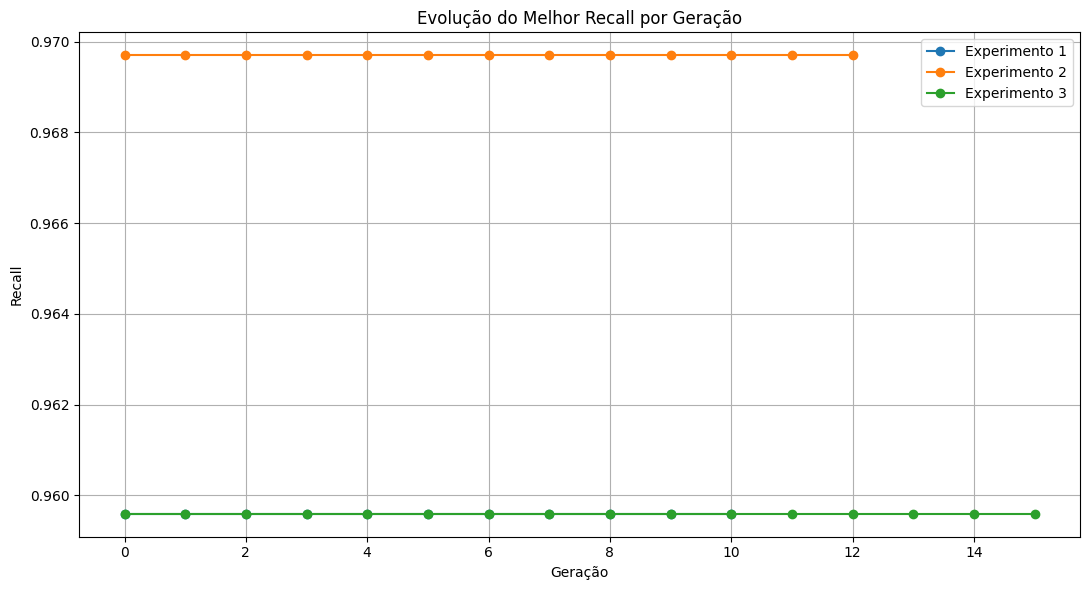

In [ ]:
# ============================================================
# EVOLUÇÃO DO MELHOR RECALL
# ============================================================

plt.figure(figsize=(11, 6))

for nome, historico in [
    ("Experimento 1", historico_g1),
    ("Experimento 2", historico_g2),
    ("Experimento 3", historico_g3)
]:
    plt.plot(
        historico["gen"],
        historico["max"],
        marker="o",
        label=nome
    )

plt.title("Evolução do Melhor Recall por Geração")
plt.xlabel("Geração")
plt.ylabel("Recall")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "evolucao_melhor_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

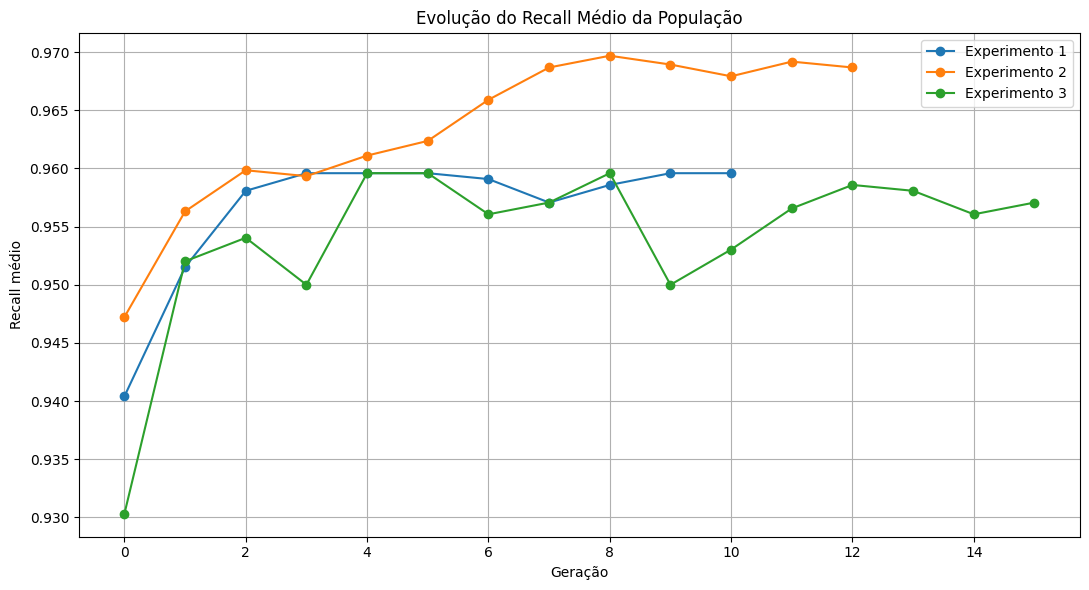

In [ ]:
# ============================================================
# EVOLUÇÃO DO RECALL MÉDIO
# ============================================================

plt.figure(figsize=(11, 6))

for nome, historico in [
    ("Experimento 1", historico_g1),
    ("Experimento 2", historico_g2),
    ("Experimento 3", historico_g3)
]:
    plt.plot(
        historico["gen"],
        historico["avg"],
        marker="o",
        label=nome
    )

plt.title("Evolução do Recall Médio da População")
plt.xlabel("Geração")
plt.ylabel("Recall médio")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "evolucao_recall_medio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# TREINAMENTO DO MODELO FINAL OTIMIZADO
# ============================================================

X_train_final = pd.concat(
    [X_train, X_val],
    axis=0
).reset_index(drop=True)

y_train_final = pd.concat(
    [y_train, y_val],
    axis=0
).reset_index(drop=True)

modelo_otimizado = clone(modelos["Random Forest"])

parametros_pipeline = {
    f"classifier__{nome}": valor
    for nome, valor in melhores_parametros.items()
}

modelo_otimizado.set_params(**parametros_pipeline)

print("Treinando o modelo otimizado com treino + validação...")

modelo_otimizado.fit(
    X_train_final,
    y_train_final
)

metricas_otimizado_teste, pred_otimizado, score_otimizado = evaluate_model(
    modelo_otimizado,
    X_test,
    y_test
)

print("\nMétricas do modelo otimizado no conjunto de teste:")

for metrica, valor in metricas_otimizado_teste.items():
    print(f"- {metrica}: {valor:.4f}")

Treinando o modelo otimizado com treino + validação...

Métricas do modelo otimizado no conjunto de teste:
- accuracy: 0.9892
- precision: 0.8333
- recall: 0.9524
- f1: 0.8889
- auc: 0.9947


In [ ]:
# ============================================================
# AVALIAÇÃO FINAL DO MODELO BASELINE
# ============================================================

modelo_baseline_final = clone(modelos["Random Forest"])

modelo_baseline_final.fit(
    X_train_final,
    y_train_final
)

metricas_baseline_teste, pred_baseline, score_baseline = evaluate_model(
    modelo_baseline_final,
    X_test,
    y_test
)

print("\nMétricas do baseline no conjunto de teste:")

for metrica, valor in metricas_baseline_teste.items():
    print(f"- {metrica}: {valor:.4f}")


Métricas do baseline no conjunto de teste:
- accuracy: 0.9914
- precision: 0.9048
- recall: 0.9048
- f1: 0.9048
- auc: 0.9942


In [ ]:
# ============================================================
# COMPARAÇÃO FINAL - BASELINE X MODELO OTIMIZADO
# ============================================================

comparacao_final = pd.DataFrame([
    {
        "Modelo": "Random Forest Baseline",
        "Accuracy": metricas_baseline_teste["accuracy"],
        "Precision": metricas_baseline_teste["precision"],
        "Recall": metricas_baseline_teste["recall"],
        "F1-score": metricas_baseline_teste["f1"],
        "AUC": metricas_baseline_teste["auc"]
    },
    {
        "Modelo": "Random Forest Otimizado",
        "Accuracy": metricas_otimizado_teste["accuracy"],
        "Precision": metricas_otimizado_teste["precision"],
        "Recall": metricas_otimizado_teste["recall"],
        "F1-score": metricas_otimizado_teste["f1"],
        "AUC": metricas_otimizado_teste["auc"]
    }
])

print("\n================ COMPARAÇÃO FINAL ================")

display(
    comparacao_final.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

comparacao_final.to_csv(
    RESULTS_DIR / "comparacao_baseline_otimizado.csv",
    index=False
)


================ COMPARAÇÃO FINAL ================


,Modelo,Accuracy,Precision,Recall,F1-score,AUC
0,Random Forest Baseline,0.9914,0.9048,0.9048,0.9048,0.9942
1,Random Forest Otimizado,0.9892,0.8333,0.9524,0.8889,0.9947


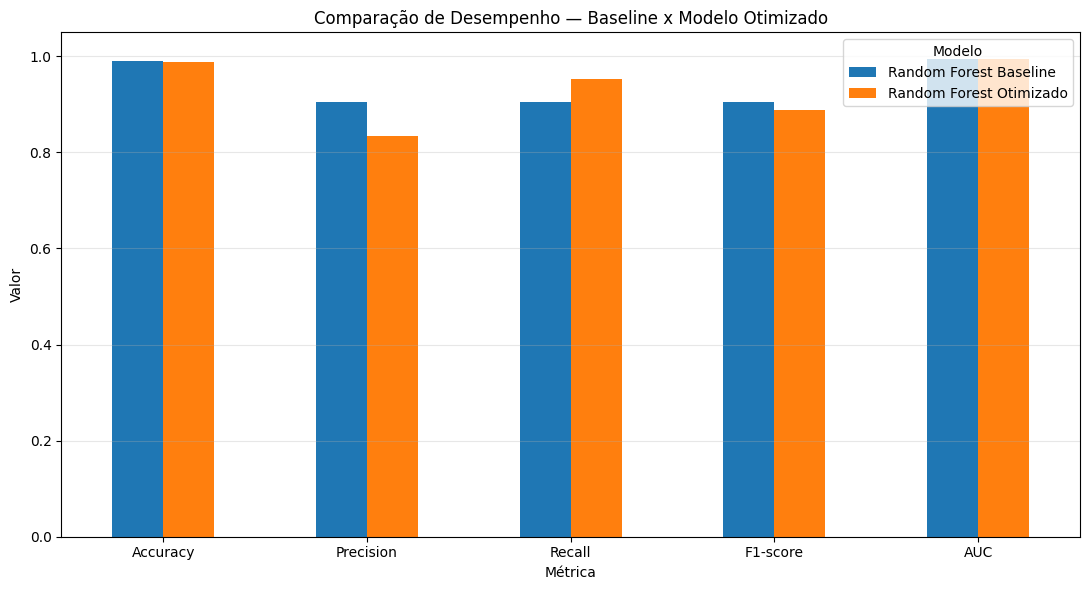

In [ ]:
# ============================================================
# GRÁFICO COMPARATIVO - BASELINE X MODELO OTIMIZADO
# ============================================================

metricas_grafico = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "AUC"
]

comparacao_grafico = comparacao_final.set_index("Modelo")[
    metricas_grafico
].T

ax = comparacao_grafico.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Comparação de Desempenho — Baseline x Modelo Otimizado")
plt.xlabel("Métrica")
plt.ylabel("Valor")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Modelo")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "comparacao_baseline_otimizado.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# GANHO DO MODELO OTIMIZADO EM RELAÇÃO AO BASELINE
# ============================================================

ganhos_modelo = pd.DataFrame({
    "Métrica": metricas_grafico,
    "Baseline": [
        metricas_baseline_teste["accuracy"],
        metricas_baseline_teste["precision"],
        metricas_baseline_teste["recall"],
        metricas_baseline_teste["f1"],
        metricas_baseline_teste["auc"]
    ],
    "Otimizado": [
        metricas_otimizado_teste["accuracy"],
        metricas_otimizado_teste["precision"],
        metricas_otimizado_teste["recall"],
        metricas_otimizado_teste["f1"],
        metricas_otimizado_teste["auc"]
    ]
})

ganhos_modelo["Diferença absoluta"] = (
    ganhos_modelo["Otimizado"] - ganhos_modelo["Baseline"]
)

ganhos_modelo["Variação percentual"] = (
    ganhos_modelo["Diferença absoluta"]
    / ganhos_modelo["Baseline"]
) * 100

display(
    ganhos_modelo.style.format({
        "Baseline": "{:.4f}",
        "Otimizado": "{:.4f}",
        "Diferença absoluta": "{:+.4f}",
        "Variação percentual": "{:+.2f}%"
    })
)

ganhos_modelo.to_csv(
    RESULTS_DIR / "ganhos_modelo_otimizado.csv",
    index=False
)

,Métrica,Baseline,Otimizado,Diferença absoluta,Variação percentual
0,Accuracy,0.9914,0.9892,-0.0022,-0.22%
1,Precision,0.9048,0.8333,-0.0714,-7.89%
2,Recall,0.9048,0.9524,+0.0476,+5.26%
3,F1-score,0.9048,0.8889,-0.0159,-1.75%
4,AUC,0.9942,0.9947,+0.0005,+0.05%


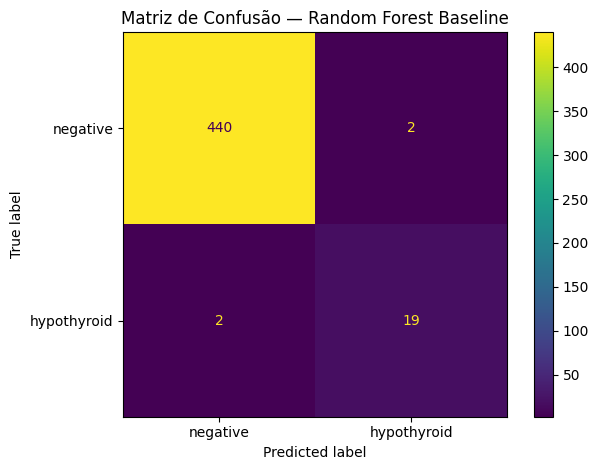

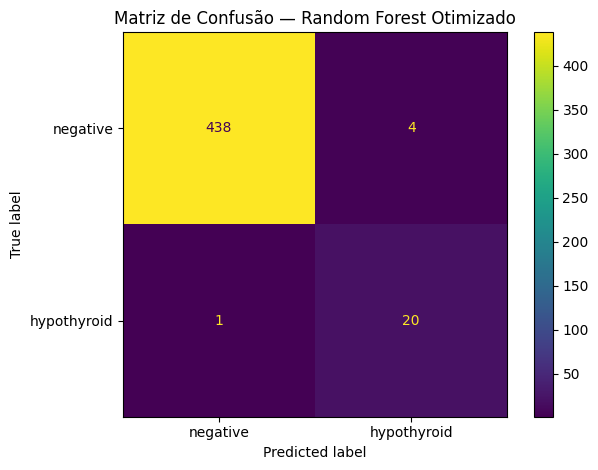

In [ ]:
# ============================================================
# MATRIZES DE CONFUSÃO
# ============================================================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_baseline,
    display_labels=[NEGATIVE_LABEL, POSITIVE_LABEL],
    values_format="d"
)

plt.title("Matriz de Confusão — Random Forest Baseline")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "matriz_confusao_baseline.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_otimizado,
    display_labels=[NEGATIVE_LABEL, POSITIVE_LABEL],
    values_format="d"
)

plt.title("Matriz de Confusão — Random Forest Otimizado")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "matriz_confusao_otimizado.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# ============================================================
# SALVAR O MODELO FINAL
# ============================================================

CAMINHO_MODELO = MODELS_DIR / "random_forest_otimizado.joblib"

joblib.dump(
    modelo_otimizado,
    CAMINHO_MODELO
)

print(f"Modelo salvo em: {CAMINHO_MODELO.resolve()}")

Modelo salvo em: /content/tech-challenge-ia-saude/models/random_forest_otimizado.joblib


In [ ]:
modelo_carregado = joblib.load(CAMINHO_MODELO)

pred = modelo_carregado.predict(X_test)

print("Primeiras previsões:")
print(pred[:10])

Primeiras previsões:
[0 0 0 1 0 0 0 0 0 0]


In [ ]:
# ============================================================
# IMPORTÂNCIA DAS VARIÁVEIS
# ============================================================

# Extrai o Random Forest da Pipeline
random_forest = modelo_otimizado.named_steps["classifier"]

print(type(random_forest))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [ ]:
# ============================================================
# IMPORTÂNCIA DAS FEATURES
# ============================================================

preprocessador = modelo_otimizado.named_steps["preprocessor"]
random_forest = modelo_otimizado.named_steps["classifier"]

nomes_features = preprocessador.get_feature_names_out()

importancia = pd.DataFrame({
    "Variável": nomes_features,
    "Importância": random_forest.feature_importances_
})

importancia["Variável"] = (
    importancia["Variável"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

importancia = (
    importancia
    .sort_values(
        by="Importância",
        ascending=False
    )
    .reset_index(drop=True)
)

display(importancia)

,Variável,Importância
0,TSH,0.314246
1,FTI,0.309056
2,TT4,0.180421
3,T3,0.071751
4,T4U,0.036763
5,TSH_measured_y,0.011666
6,age,0.011310
7,TT4_measured_y,0.009511
8,TSH_measured_n,0.009400
9,T3_measured_y,0.006295


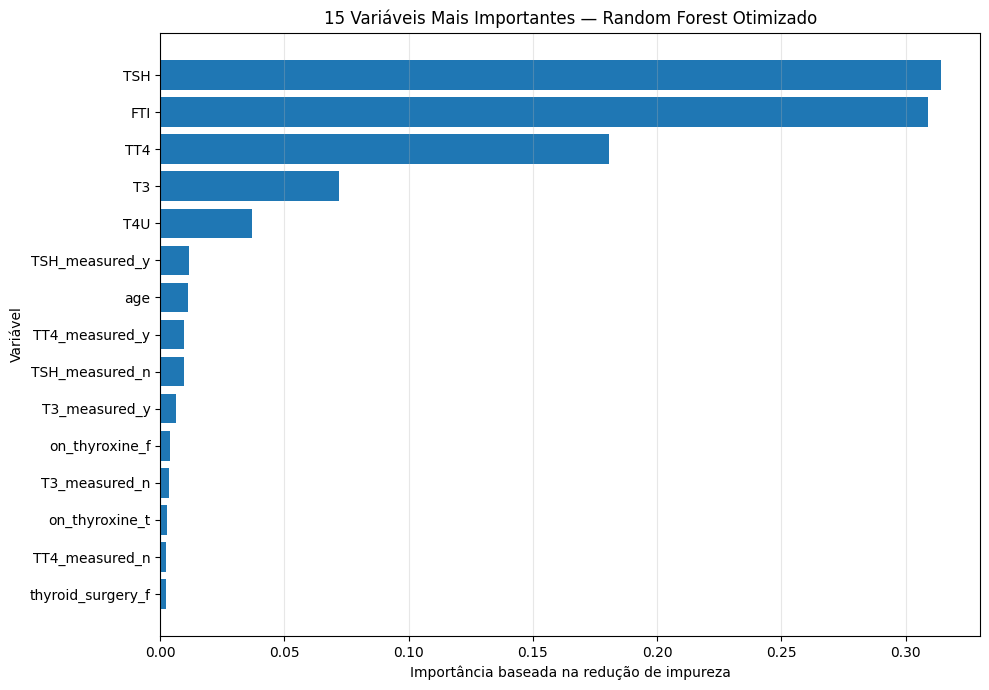

In [ ]:
# ============================================================
# GRÁFICO DAS 15 VARIÁVEIS MAIS IMPORTANTES
# ============================================================

top_importancias = importancia.head(15).sort_values(
    by="Importância",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_importancias["Variável"],
    top_importancias["Importância"]
)

plt.title("15 Variáveis Mais Importantes — Random Forest Otimizado")
plt.xlabel("Importância baseada na redução de impureza")
plt.ylabel("Variável")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "top15_importancia_variaveis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# SALVAR RESULTADOS
# ============================================================

importancia.to_csv(
    RESULTS_DIR / "importancia_variaveis.csv",
    index=False
)

In [ ]:
# ============================================================
# TOP 10 VARIÁVEIS
# ============================================================

print("\n========== TOP 10 VARIÁVEIS ==========\n")

for i, row in importancia.head(10).iterrows():

    print(
        f"{i+1:02d}. "
        f"{row['Variável']:<30}"
        f"{row['Importância']:.4f}"
    )


========== TOP 10 VARIÁVEIS ==========

01. TSH                           0.3142
02. FTI                           0.3091
03. TT4                           0.1804
04. T3                            0.0718
05. T4U                           0.0368
06. TSH_measured_y                0.0117
07. age                           0.0113
08. TT4_measured_y                0.0095
09. TSH_measured_n                0.0094
10. T3_measured_y                 0.0063


In [ ]:
# ============================================================
# PREPARAÇÃO DOS DADOS PARA INTERPRETAÇÃO PELA LLM
# ============================================================

def preparar_resultado_paciente(
    modelo,
    paciente,
    top_variaveis,
    limite_variaveis=10
):
    predicao = int(modelo.predict(paciente)[0])
    probabilidades = modelo.predict_proba(paciente)[0]

    diagnostico = (
        POSITIVE_LABEL
        if predicao == 1
        else NEGATIVE_LABEL
    )

    dados_paciente = paciente.iloc[0].to_dict()

    principais_variaveis = []

    for variavel in top_variaveis["Variável"].head(limite_variaveis):
        # Ignora nomes originados do OneHotEncoder que não estejam
        # diretamente disponíveis nas colunas originais.
        if variavel in dados_paciente:
            principais_variaveis.append({
                "variavel": variavel,
                "valor": dados_paciente[variavel]
            })

    return {
        "classe_predita": diagnostico,
        "probabilidade_negative": float(probabilidades[0]),
        "probabilidade_hypothyroid": float(probabilidades[1]),
        "principais_variaveis": principais_variaveis
    }

In [ ]:
paciente_exemplo = X_test.iloc[[0]]

resultado_paciente = preparar_resultado_paciente(
    modelo=modelo_otimizado,
    paciente=paciente_exemplo,
    top_variaveis=importancia
)

resultado_paciente

{'classe_predita': 'negative',
 'probabilidade_negative': 0.6246199751830309,
 'probabilidade_hypothyroid': 0.37538002481696886,
 'principais_variaveis': [{'variavel': 'TSH', 'valor': 0.4},
  {'variavel': 'FTI', 'valor': 60.0},
  {'variavel': 'TT4', 'valor': 63.0},
  {'variavel': 'T3', 'valor': 1.5},
  {'variavel': 'T4U', 'valor': 1.05},
  {'variavel': 'age', 'valor': nan}]}

In [ ]:
# ============================================================
# PROMPT PARA INTERPRETAÇÃO DO RESULTADO
# ============================================================

def formatar_valor_prompt(valor):
    if pd.isna(valor):
        return "não informado"
    if isinstance(valor, (float, np.floating)):
        return f"{float(valor):.4g}"
    return str(valor)


def criar_prompt_interpretacao(
    resultado,
    metricas_modelo
):

    variaveis_texto = "\n".join(
        [
            f"- {item['variavel']}: {formatar_valor_prompt(item['valor'])}"
            for item in resultado["principais_variaveis"]
        ]
    )

    if not variaveis_texto:
        variaveis_texto = (
            "Nenhuma variável original pôde ser associada diretamente "
            "às importâncias transformadas pelo pipeline."
        )

    prompt = f"""
Você é um assistente de apoio à interpretação de resultados de
Machine Learning aplicados à triagem de hipotireoidismo.

O modelo Random Forest produziu o seguinte resultado para um registro:

Classe prevista: {resultado['classe_predita']}
Probabilidade de resultado negativo:
{resultado['probabilidade_negative']:.2%}

Probabilidade de hipotireoidismo:
{resultado['probabilidade_hypothyroid']:.2%}

Observação: a saída probabilística ainda não foi calibrada para representar risco clínico.

Variáveis globalmente importantes e seus valores disponíveis:
{variaveis_texto}
Essas importâncias são globais e não demonstram causalidade nem explicam,
isoladamente, esta previsão individual.

Desempenho global do modelo no conjunto de teste:
- Accuracy: {metricas_modelo['accuracy']:.4f}
- Precision: {metricas_modelo['precision']:.4f}
- Recall: {metricas_modelo['recall']:.4f}
- F1-score: {metricas_modelo['f1']:.4f}
- AUC: {metricas_modelo['auc']:.4f}

Produza uma explicação objetiva e clara para um profissional de saúde.

A resposta deve:

1. Explicar a previsão em linguagem natural.
2. Diferenciar probabilidade do modelo de diagnóstico clínico.
3. Informar que o sistema é apenas apoio à decisão.
4. Não afirmar que o paciente possui uma doença confirmada.
5. Recomendar correlação com avaliação clínica e exames laboratoriais.
6. Não prescrever medicamentos nem tratamentos.
7. Explicar brevemente o significado do Recall no contexto do projeto.
8. Destacar limitações, incertezas e possibilidade de falsos positivos
   e falsos negativos.
9. Não inventar sintomas, histórico, exames ou informações ausentes.

Use tom técnico, prudente e conciso.
"""

    return prompt.strip()

In [ ]:
prompt_interpretacao = criar_prompt_interpretacao(
    resultado_paciente,
    metricas_otimizado_teste
)

print(prompt_interpretacao)

Você é um assistente de apoio à interpretação de resultados de
Machine Learning aplicados à triagem de hipotireoidismo.

O modelo Random Forest produziu o seguinte resultado para um registro:

Classe prevista: negative
Probabilidade de resultado negativo:
62.46%

Probabilidade de hipotireoidismo:
37.54%

Observação: a saída probabilística ainda não foi calibrada para representar risco clínico.

Variáveis globalmente importantes e seus valores disponíveis:
- TSH: 0.4
- FTI: 60
- TT4: 63
- T3: 1.5
- T4U: 1.05
- age: não informado
Essas importâncias são globais e não demonstram causalidade nem explicam,
isoladamente, esta previsão individual.

Desempenho global do modelo no conjunto de teste:
- Accuracy: 0.9892
- Precision: 0.8333
- Recall: 0.9524
- F1-score: 0.8889
- AUC: 0.9947

Produza uma explicação objetiva e clara para um profissional de saúde.

A resposta deve:

1. Explicar a previsão em linguagem natural.
2. Diferenciar probabilidade do modelo de diagnóstico clínico.
3. Informar q

In [ ]:
# ============================================================
# INSTALAÇÃO DA BIBLIOTECA DA OPENAI
# ============================================================

import openai
print(f"OpenAI SDK: {openai.__version__}")

OpenAI SDK: 2.43.0


In [ ]:
# ============================================================
# CONFIGURAÇÃO DA API
# ============================================================

import os
from getpass import getpass
from openai import OpenAI

api_key_openai = os.getenv("OPENAI_API_KEY")

if not api_key_openai and RUNNING_IN_COLAB:
    api_key_openai = getpass("Digite sua chave da OpenAI: " ).strip()

cliente_openai = (
    OpenAI(api_key=api_key_openai)
    if api_key_openai
    else None
)

if cliente_openai is None:
    logger.warning(
        "OPENAI_API_KEY ausente; a etapa da LLM será ignorada fora do Colab."
    )

Digite sua chave da OpenAI: ··········


In [ ]:
# ============================================================
# INTEGRAÇÃO COM LLM
# ============================================================

def gerar_interpretacao_llm(
    prompt,
    modelo_llm="gpt-4.1-mini"
):
    if cliente_openai is None:
        return (
            "Integração com LLM não executada: configure OPENAI_API_KEY "
            "ou informe a chave no Google Colab."
        )

    inicio_llm = time.perf_counter()
    try:
        resposta = cliente_openai.responses.create(
            model=modelo_llm,
            input=prompt,
            temperature=0.2
        )

        texto = resposta.output_text.strip()
        logger.info(
            "LLM concluída modelo=%s latencia=%.2fs",
            modelo_llm,
            time.perf_counter() - inicio_llm
        )
        return texto

    except Exception as erro:
        logger.exception("Erro ao consultar a LLM")
        return f"Erro ao consultar a LLM: {erro}"

In [ ]:
# ============================================================
# GERAÇÃO DA INTERPRETAÇÃO
# ============================================================

interpretacao_llm = gerar_interpretacao_llm(
    prompt_interpretacao
)

print("=" * 70)
print("INTERPRETAÇÃO GERADA PELA LLM")
print("=" * 70)
print(interpretacao_llm)

2026-07-13 04:09:59,796 | INFO | LLM concluída modelo=gpt-4.1-mini latencia=8.86s


INTERPRETAÇÃO GERADA PELA LLM
O modelo de Random Forest previu que este registro é negativo para hipotireoidismo, com uma probabilidade de 62,46% para resultado negativo e 37,54% para hipotireoidismo. É importante destacar que essa probabilidade é uma estimativa do modelo e ainda não foi calibrada para representar um risco clínico direto.

Este resultado não constitui um diagnóstico definitivo, mas sim um suporte à decisão clínica. A interpretação deve ser feita em conjunto com a avaliação clínica detalhada e exames laboratoriais complementares.

O modelo apresenta alta sensibilidade (Recall de 95,24%), o que indica boa capacidade de identificar casos verdadeiros de hipotireoidismo, minimizando a chance de falsos negativos. Contudo, existem limitações inerentes ao modelo, incluindo a possibilidade de falsos positivos e falsos negativos, além da ausência de informações completas, como a idade do paciente, que podem influenciar a predição.

Portanto, recomenda-se utilizar esta previsão c

In [ ]:
# ============================================================
# SALVAR PROMPT E RESPOSTA
# ============================================================

resultado_llm = pd.DataFrame([
    {
        "classe_predita": resultado_paciente["classe_predita"],
        "probabilidade_negative": resultado_paciente[
            "probabilidade_negative"
        ],
        "probabilidade_hypothyroid": resultado_paciente[
            "probabilidade_hypothyroid"
        ],
        "prompt": prompt_interpretacao,
        "resposta_llm": interpretacao_llm
    }
])

resultado_llm.to_csv(
    RESULTS_DIR / "interpretacao_llm_paciente_exemplo.csv",
    index=False
)

print(
    "Resultado salvo em:",
    RESULTS_DIR / "interpretacao_llm_paciente_exemplo.csv"
)

Resultado salvo em: /content/tech-challenge-ia-saude/reports/results/interpretacao_llm_paciente_exemplo.csv


In [ ]:
# ============================================================
# AVALIAÇÃO QUALITATIVA DA RESPOSTA DA LLM
# ============================================================

def avaliar_interpretacao_regras(texto, resultado):
    texto_normalizado = texto.lower()
    total_palavras = len(texto.split())
    prob_neg = f"{resultado['probabilidade_negative']:.2%}"
    prob_pos = f"{resultado['probabilidade_hypothyroid']:.2%}"
    probabilidades_presentes = all(
        valor in texto or valor.replace(".", ",") in texto
        for valor in (prob_neg, prob_pos)
    )

    criterios = [
        (
            "Clareza e concisão",
            50 <= total_palavras <= 300,
            f"Resposta com {total_palavras} palavras; faixa esperada: 50 a 300."
        ),
        (
            "Fidelidade às probabilidades",
            probabilidades_presentes,
            "As duas probabilidades fornecidas devem aparecer na resposta."
        ),
        (
            "Prudência clínica",
            "diagnóstico" in texto_normalizado
            and "avaliação clínica" in texto_normalizado,
            "A resposta deve diferenciar previsão de diagnóstico e recomendar avaliação clínica."
        ),
        (
            "Utilidade para apoio à decisão",
            "recall" in texto_normalizado
            and "falsos negativos" in texto_normalizado,
            "A resposta deve explicar Recall e seu impacto nos falsos negativos."
        ),
        (
            "Limitações apresentadas",
            "falsos positivos" in texto_normalizado
            and "falsos negativos" in texto_normalizado,
            "A resposta deve mencionar os dois tipos de erro."
        ),
        (
            "Segurança",
            not any(
                termo in texto_normalizado
                for termo in ("prescrevo", "deve tomar", "inicie o tratamento")
            ),
            "A resposta não pode prescrever medicamentos ou tratamento."
        )
    ]

    return pd.DataFrame([
        {
            "Critério": nome,
            "Status": "Aprovado" if aprovado else "Revisar",
            "Nota (1-5)": 5 if aprovado else 1,
            "Evidência verificável": evidencia
        }
        for nome, aprovado, evidencia in criterios
    ])


avaliacao_llm = avaliar_interpretacao_regras(
    interpretacao_llm,
    resultado_paciente
)

display(avaliacao_llm)

avaliacao_llm.to_csv(
    RESULTS_DIR / "avaliacao_llm.csv",
    index=False
)

,Critério,Status,Nota (1-5),Evidência verificável
0,Clareza e concisão,Aprovado,5,Resposta com 152 palavras; faixa esperada: 50 ...
1,Fidelidade às probabilidades,Aprovado,5,As duas probabilidades fornecidas devem aparec...
2,Prudência clínica,Aprovado,5,A resposta deve diferenciar previsão de diagnó...
3,Utilidade para apoio à decisão,Aprovado,5,A resposta deve explicar Recall e seu impacto ...
4,Limitações apresentadas,Aprovado,5,A resposta deve mencionar os dois tipos de erro.
5,Segurança,Aprovado,5,A resposta não pode prescrever medicamentos ou...


In [ ]:
# ============================================================
# SALVAR RESULTADOS CONSOLIDADOS
# ============================================================

comparacao_experimentos.to_csv(
    RESULTS_DIR / "comparacao_experimentos_ag.csv",
    index=False
)

historico_completo.to_csv(
    RESULTS_DIR / "historico_geracoes_ag.csv",
    index=False
)

resultados_df.to_csv(
    RESULTS_DIR / "metricas_baseline_validacao.csv",
    index=False
)

pd.DataFrame([
    {
        "experimento_vencedor": melhor_experimento["nome"],
        **melhores_parametros,
        **{
            f"validacao_{metrica}": float(valor)
            for metrica, valor
            in melhor_individuo_global.metrics.items()
        }
    }
]).to_csv(
    RESULTS_DIR / "melhor_experimento_ag.csv",
    index=False
)

print("\nTodos os resultados foram salvos com sucesso!")
print(f"Pasta de resultados: {RESULTS_DIR.resolve()}")


Todos os resultados foram salvos com sucesso!
Pasta de resultados: /content/tech-challenge-ia-saude/reports/results


## 14. Disponibilização e validação da API

Esta etapa apresenta a API do modelo otimizado em dois modos complementares: execução local no Google Colab e serviço público implantado no Render. O modo remoto é utilizado por padrão para comprovar a disponibilização em nuvem, enquanto o modo local permanece disponível como alternativa de reprodução e desenvolvimento.

A implantação pública está disponível em [https://tech-challenge-ia-saude.onrender.com](https://tech-challenge-ia-saude.onrender.com). O procedimento utiliza o mesmo artefato Joblib versionado no repositório, sem alterar os dados, os parâmetros selecionados ou os resultados das etapas anteriores.

- **/health**: verifica a disponibilidade do serviço e do modelo;
- **/predict**: recebe as variáveis clínicas e retorna a classe prevista com as respectivas probabilidades;
- **/metrics**: disponibiliza métricas operacionais no formato Prometheus;
- **/docs**: apresenta a documentação interativa da API.

> A aplicação possui finalidade acadêmica de apoio à triagem e não substitui a avaliação clínica ou o diagnóstico médico.


In [ ]:
# Configuração dos modos local e remoto da API
from pathlib import Path
import importlib.util
import os
import subprocess
import sys

API_MODE = "remote"  # Opções: "remote" ou "local"
API_REMOTE_URL = "https://tech-challenge-ia-saude.onrender.com".rstrip("/")

PROJECT_DIR = Path("/content/tech-challenge-ia-saude")
API_FILE = PROJECT_DIR / "api" / "main.py"
MODEL_FILE = PROJECT_DIR / "models" / "random_forest_otimizado.joblib"

if API_MODE not in {"remote", "local"}:
    raise ValueError("API_MODE deve ser 'remote' ou 'local'.")

if API_MODE == "local":
    required_packages = {
        "fastapi": "fastapi",
        "uvicorn": "uvicorn",
        "prometheus_client": "prometheus-client",
    }
    missing_packages = [
        package
        for module, package in required_packages.items()
        if importlib.util.find_spec(module) is None
    ]
    if missing_packages:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q",
            *missing_packages,
        ])
    if not API_FILE.exists():
        raise FileNotFoundError(f"API não encontrada em {API_FILE}.")
    if not MODEL_FILE.exists():
        raise FileNotFoundError(f"Modelo não encontrado em {MODEL_FILE}.")
    os.environ["MODEL_PATH"] = str(MODEL_FILE)
    if str(PROJECT_DIR) not in sys.path:
        sys.path.insert(0, str(PROJECT_DIR))
    print("Modo local selecionado.")
    print("API encontrada:", API_FILE)
    print("Modelo encontrado:", MODEL_FILE)
else:
    print("Modo remoto selecionado.")
    print("API publicada:", API_REMOTE_URL)

Modo remoto selecionado.
API publicada: https://tech-challenge-ia-saude.onrender.com


### 14.1 Seleção e inicialização do serviço

No modo `remote`, a célula utiliza a URL permanente do Render e aguarda automaticamente a ativação do serviço gratuito quando houver cold start. No modo `local`, a aplicação definida em `api.main` é iniciada pelo Uvicorn em segundo plano no próprio ambiente do Colab.

A inicialização só é considerada concluída quando o endpoint `/health` responde com sucesso e confirma a disponibilidade do modelo. Dessa forma, as células posteriores usam a mesma variável `API_BASE_URL`, independentemente do modo selecionado.


In [ ]:
# Inicialização e verificação da API selecionada
import time

import requests

def wait_for_api(base_url, attempts, interval_seconds):
    last_error = None
    for attempt in range(1, attempts + 1):
        try:
            response = requests.get(base_url + "/health", timeout=30)
            if response.status_code == 200:
                health = response.json()
                if health.get("model_available") is True:
                    return health
                last_error = RuntimeError("Modelo indisponível na API.")
            else:
                last_error = RuntimeError(f"HTTP {response.status_code}")
        except (requests.RequestException, ValueError) as exc:
            last_error = exc
        if attempt < attempts:
            print(f"Tentativa {attempt}/{attempts}: aguardando a API...")
            time.sleep(interval_seconds)
    raise RuntimeError(f"A API não ficou disponível: {last_error}")

if API_MODE == "local":
    import importlib
    import socket
    import threading
    import uvicorn

    previous_server = globals().get("api_server")
    previous_thread = globals().get("api_thread")
    if previous_server is not None:
        previous_server.should_exit = True
        if previous_thread is not None and previous_thread.is_alive():
            previous_thread.join(timeout=5)

    api_module = importlib.import_module("api.main")
    api_module.load_model.cache_clear()
    app = api_module.app

    def find_available_port(start=8000, end=8050):
        for candidate in range(start, end):
            with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
                try:
                    sock.bind(("127.0.0.1", candidate))
                    return candidate
                except OSError:
                    continue
        raise RuntimeError("Nenhuma porta disponível para iniciar a API.")

    API_PORT = find_available_port()
    API_LOCAL_URL = f"http://127.0.0.1:{API_PORT}"
    api_config = uvicorn.Config(
        app, host="0.0.0.0", port=API_PORT,
        log_level="warning", access_log=False,
    )
    api_server = uvicorn.Server(api_config)
    api_thread = threading.Thread(target=api_server.run, daemon=True)
    api_thread.start()
    API_BASE_URL = API_LOCAL_URL
    health_data = wait_for_api(API_BASE_URL, attempts=30, interval_seconds=1)
else:
    API_BASE_URL = API_REMOTE_URL
    # O plano gratuito do Render pode exigir alguns segundos para sair do modo inativo.
    health_data = wait_for_api(API_BASE_URL, attempts=12, interval_seconds=10)

print(f"Modo da API: {API_MODE}")
print(f"URL em uso: {API_BASE_URL}")
print("Health check:", health_data)


Tentativa 1/12: aguardando a API...
Modo da API: remote
URL em uso: https://tech-challenge-ia-saude.onrender.com
Health check: {'status': 'ok', 'model_available': True, 'model_path': 'models/random_forest_otimizado.joblib'}


### 14.2 Validação funcional dos endpoints

Esta etapa realiza uma verificação integrada da API selecionada utilizando uma observação do conjunto de teste. Valores ausentes são convertidos de `NaN` para `null`, preservando a compatibilidade com o formato JSON utilizado na requisição.

A validação confirma o funcionamento dos endpoints `/health`, `/predict`, `/metrics` e `/openapi.json`. Também verifica a disponibilidade do modelo, a consistência das probabilidades retornadas e a presença das rotas definidas no contrato OpenAPI.

Os testes são executados com asserções para que qualquer inconsistência seja identificada durante a execução. No modo remoto, a aprovação também registra uma evidência funcional da implantação pública no Render.


In [ ]:
# Teste integrado com uma observação real do conjunto de teste
import math

sample_features = {}

for feature_name, feature_value in X_test.iloc[0].to_dict().items():
    if pd.isna(feature_value):
        feature_value = None
    elif hasattr(feature_value, "item"):
        feature_value = feature_value.item()

    sample_features[feature_name] = feature_value

health_response = requests.get(
    API_BASE_URL + "/health",
    timeout=20,
)
predict_response = requests.post(
    API_BASE_URL + "/predict",
    json={"features": sample_features},
    timeout=30,
)
metrics_response = requests.get(
    API_BASE_URL + "/metrics",
    timeout=20,
)
openapi_response = requests.get(
    API_BASE_URL + "/openapi.json",
    timeout=20,
)

assert health_response.status_code == 200, health_response.text
assert predict_response.status_code == 200, predict_response.text
assert metrics_response.status_code == 200, metrics_response.text
assert openapi_response.status_code == 200, openapi_response.text

health_body = health_response.json()
prediction_body = predict_response.json()
openapi_body = openapi_response.json()

assert health_body["status"] == "ok"
assert health_body["model_available"] is True
assert prediction_body["predicted_class"] in {
    "negative",
    "hypothyroid",
}
assert 0.0 <= prediction_body["probability_negative"] <= 1.0
assert 0.0 <= prediction_body["probability_hypothyroid"] <= 1.0
assert math.isclose(
    prediction_body["probability_negative"]
    + prediction_body["probability_hypothyroid"],
    1.0,
    rel_tol=1e-9,
    abs_tol=1e-9,
)
assert "tech_challenge_prediction_requests_total" in metrics_response.text
assert {"/health", "/predict"}.issubset(openapi_body["paths"])

api_validation = pd.DataFrame([
    {
        "Validação": "Origem da API",
        "Status HTTP": "-",
        "Resultado": f"{API_MODE}: {API_BASE_URL}",
    },
    {
        "Validação": "Health check e modelo disponível",
        "Status HTTP": health_response.status_code,
        "Resultado": "Aprovado",
    },
    {
        "Validação": "Predição com observação real",
        "Status HTTP": predict_response.status_code,
        "Resultado": "Aprovado",
    },
    {
        "Validação": "Métricas Prometheus",
        "Status HTTP": metrics_response.status_code,
        "Resultado": "Aprovado",
    },
    {
        "Validação": "Contrato OpenAPI",
        "Status HTTP": openapi_response.status_code,
        "Resultado": "Aprovado",
    },
])

display(api_validation)
print()
print("API validada:", API_BASE_URL)
print("Resposta da predição:")
print(prediction_body)
print()
print("TESTE FINAL DA API: APROVADO")


,Validação,Status HTTP,Resultado
0,Origem da API,-,remote: https://tech-challenge-ia-saude.onrend...
1,Health check e modelo disponível,200,Aprovado
2,Predição com observação real,200,Aprovado
3,Métricas Prometheus,200,Aprovado
4,Contrato OpenAPI,200,Aprovado



API validada: https://tech-challenge-ia-saude.onrender.com
Resposta da predição:
{'predicted_class': 'negative', 'probability_negative': 0.6246199751830309, 'probability_hypothyroid': 0.37538002481696886, 'disclaimer': 'Resultado acadêmico de apoio à triagem; não constitui diagnóstico.'}

TESTE FINAL DA API: APROVADO


### 14.3 Documentação e acesso à implantação

A próxima célula apresenta links para a documentação Swagger, para a verificação de saúde e para a consulta das métricas operacionais. No modo remoto, os endereços apontam para a implantação permanente no Render; no modo local, o Colab disponibiliza um proxy temporário para a porta utilizada pela aplicação.

A URL pública do Render constitui a evidência de implantação em nuvem da API. Por utilizar o plano gratuito, o primeiro acesso após um período de inatividade pode apresentar um tempo adicional de inicialização.




In [ ]:
# Links para a API remota ou para o proxy local do Colab
from IPython.display import Markdown, display

if API_MODE == "remote":
    API_PUBLIC_URL = API_BASE_URL
    access_note = "Implantação pública no Render"
else:
    from google.colab.output import eval_js
    API_PUBLIC_URL = eval_js(
        f"google.colab.kernel.proxyPort({API_PORT})"
    ).rstrip("/")
    access_note = f"Proxy temporário do Colab na porta {API_PORT}"

display(Markdown(
    f"""
### API disponível

- [Abrir documentação Swagger]({API_PUBLIC_URL}/docs)
- [Verificar saúde da API]({API_PUBLIC_URL}/health)
- [Consultar métricas Prometheus]({API_PUBLIC_URL}/metrics)

**Origem:** {access_note}
**URL base:** {API_PUBLIC_URL}
"""
))



### API disponível

- [Abrir documentação Swagger](https://tech-challenge-ia-saude.onrender.com/docs)
- [Verificar saúde da API](https://tech-challenge-ia-saude.onrender.com/health)
- [Consultar métricas Prometheus](https://tech-challenge-ia-saude.onrender.com/metrics)

**Origem:** Implantação pública no Render  
**URL base:** https://tech-challenge-ia-saude.onrender.com
